# Task 2: Unemployment Analysis with Python

**Goal:** Analyze unemployment rate data in India, understand the impact of Covid-19, and find seasonal trends.

**Dataset:** `Unemployment in India.csv` — monthly unemployment data for 28 Indian states (Rural & Urban), May 2019 to June 2020.

**Steps:**
1. Import libraries
2. Load & clean data
3. Explore data
4. Visualize unemployment trends over time
5. Covid-19 impact analysis
6. Seasonal / regional patterns
7. Conclusion & insights


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## Step 2: Load & Clean the Data

In [2]:
df = pd.read_csv("Unemployment in India.csv")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [4]:
# Check missing values
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [5]:
# Drop rows with missing values (a few blank rows exist in the raw file)
df = df.dropna()

# Strip whitespace from text columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Rename columns for convenience
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
})

df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (740, 9)


C:\Users\acer\AppData\Local\Temp\ipykernel_6888\666614764.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


## Step 3: Explore the Data

In [6]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716


In [7]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Number of states/regions:", df['Region'].nunique())
print("Areas:", df['Area'].unique())

Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Number of states/regions: 28
Areas: <StringArray>
['Rural', 'Urban']
Length: 2, dtype: str


In [8]:
# Average unemployment rate by Area (Rural vs Urban)
df.groupby('Area')['Unemployment_Rate'].mean()

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment_Rate, dtype: float64

## Step 4: Visualize Unemployment Trends Over Time

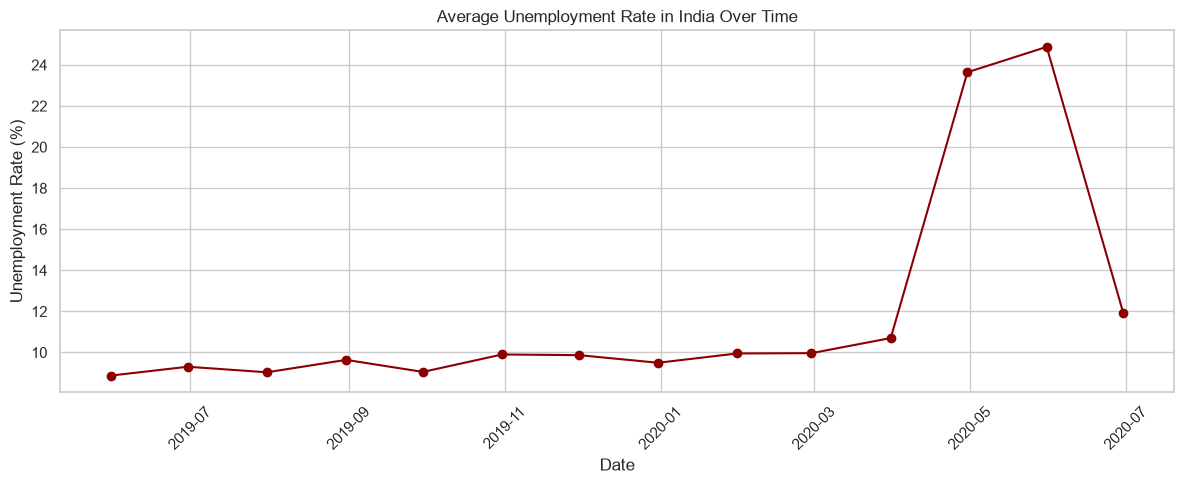

In [9]:
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], marker='o', color='darkred')
plt.title("Average Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

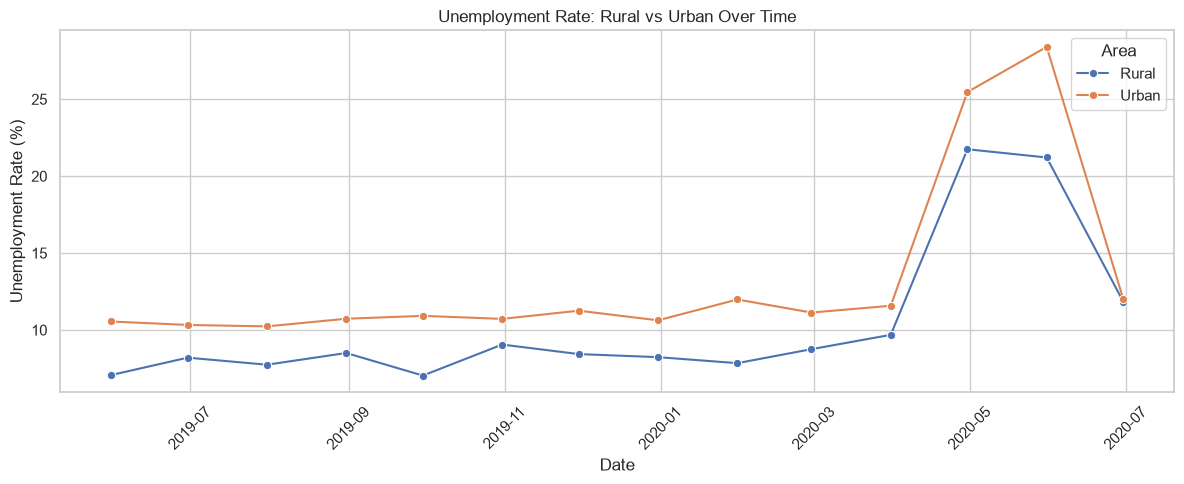

In [10]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df, x='Date', y='Unemployment_Rate', hue='Area', marker='o', errorbar=None)
plt.title("Unemployment Rate: Rural vs Urban Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

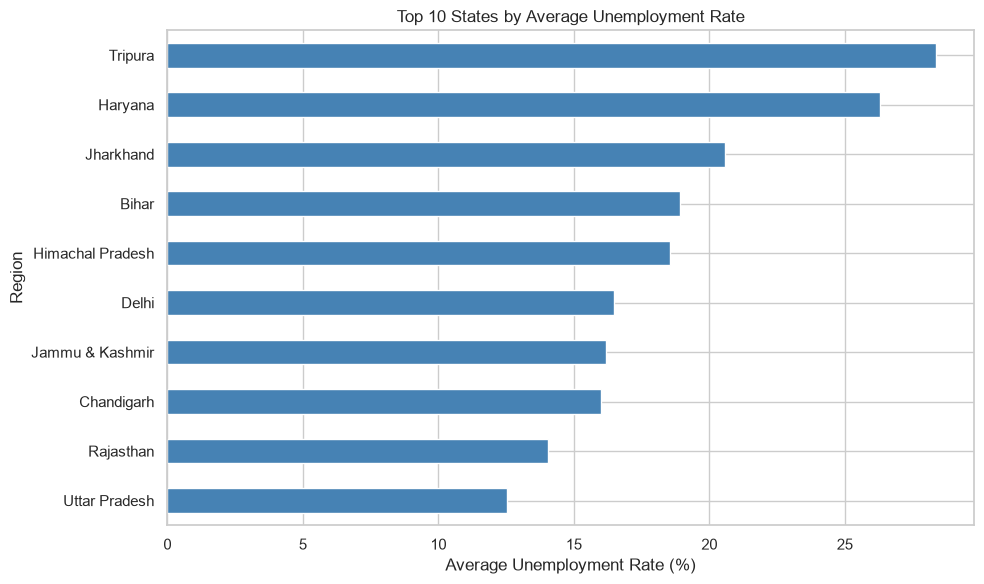

In [11]:
top10 = df.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='steelblue')
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 5: Covid-19 Impact Analysis

India's nationwide lockdown began in **late March 2020**. We'll compare unemployment before and after this point to measure Covid-19's impact.

In [12]:
lockdown_start = pd.to_datetime('2020-03-25')

df['Period'] = np.where(df['Date'] < lockdown_start, 'Pre-Lockdown', 'Lockdown/Post-Lockdown')

covid_impact = df.groupby('Period')['Unemployment_Rate'].agg(['mean', 'max', 'min'])
covid_impact

,mean,max,min
Period,,,
Lockdown/Post-Lockdown,17.774363,76.74,0.0
Pre-Lockdown,9.509534,34.69,0.0


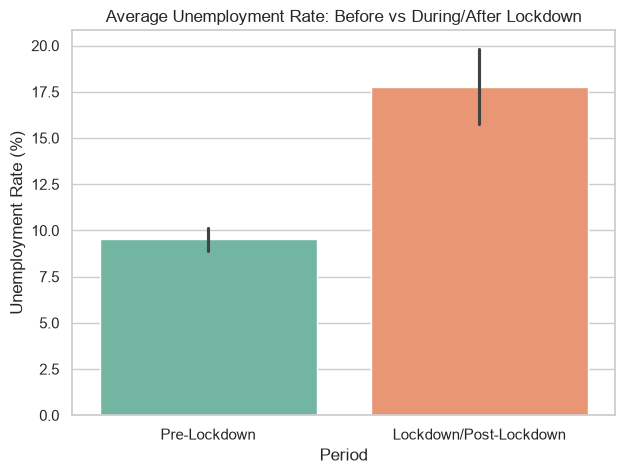

In [13]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Period', y='Unemployment_Rate', hue='Period', palette='Set2', legend=False)
plt.title("Average Unemployment Rate: Before vs During/After Lockdown")
plt.ylabel("Unemployment Rate (%)")
plt.show()

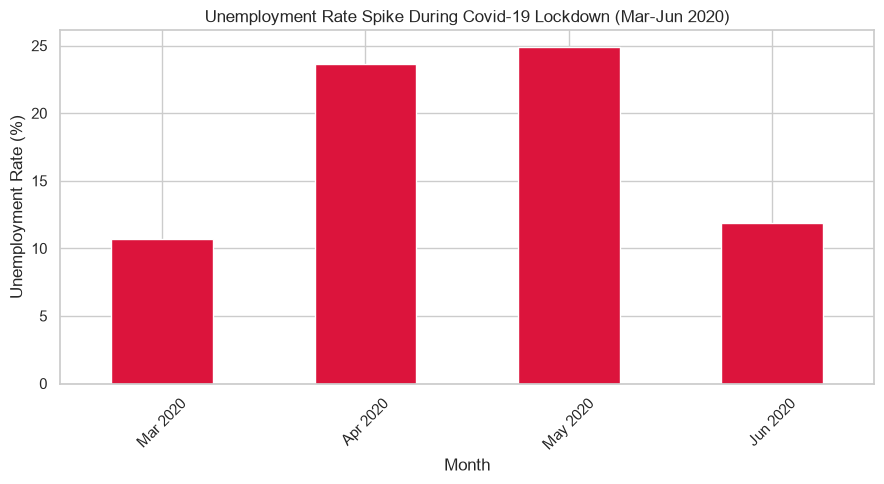

In [14]:
# Zoom into the lockdown months specifically (Mar-Jun 2020)
lockdown_period = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-30')]
monthly_lockdown = lockdown_period.groupby('Date')['Unemployment_Rate'].mean()
monthly_lockdown.index = monthly_lockdown.index.strftime('%b %Y')

plt.figure(figsize=(9,5))
monthly_lockdown.plot(kind='bar', color='crimson')
plt.title("Unemployment Rate Spike During Covid-19 Lockdown (Mar-Jun 2020)")
plt.ylabel("Unemployment Rate (%)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Unemployment rate spikes sharply in April 2020 — right after the lockdown began — confirming the massive economic impact of Covid-19 on employment in India.

## Step 6: Seasonal & Regional Patterns

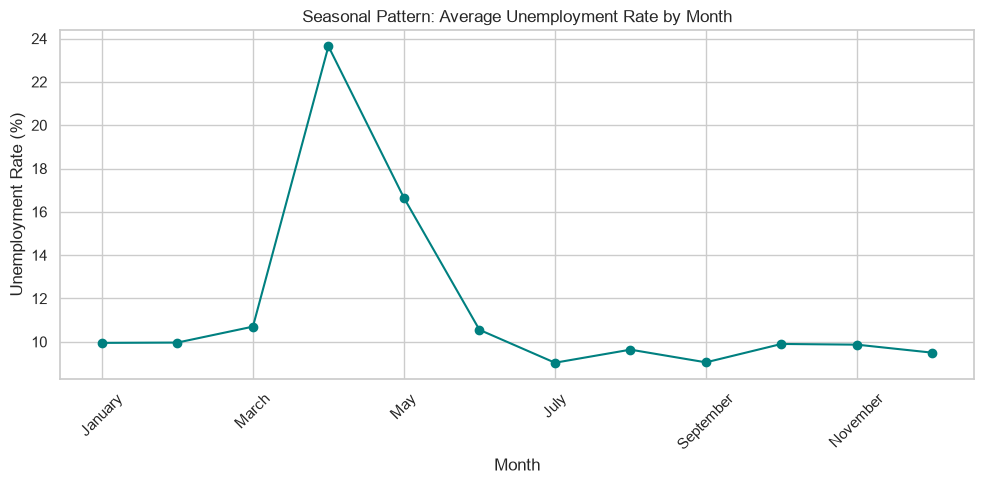

In [15]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_seasonal = df.groupby('Month')['Unemployment_Rate'].mean().reindex(month_order).dropna()

plt.figure(figsize=(10,5))
monthly_seasonal.plot(kind='line', marker='o', color='teal')
plt.title("Seasonal Pattern: Average Unemployment Rate by Month")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

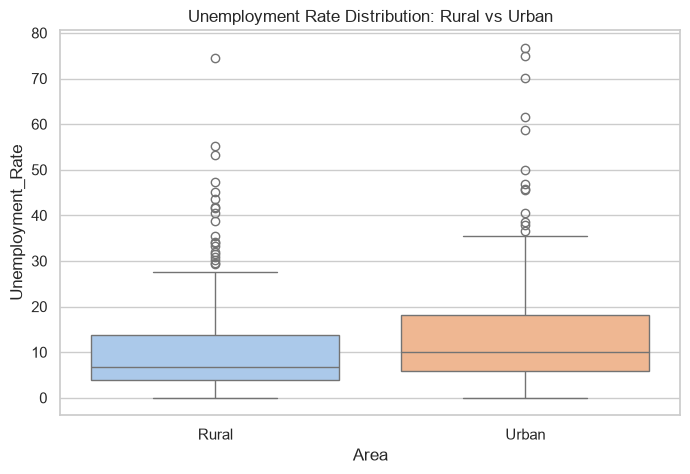

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Area', y='Unemployment_Rate', hue='Area', palette='pastel', legend=False)
plt.title("Unemployment Rate Distribution: Rural vs Urban")
plt.show()

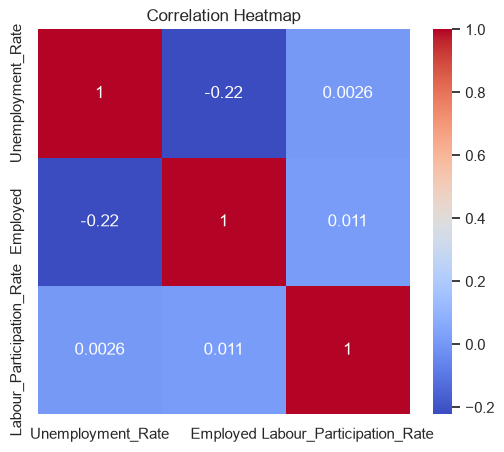

In [17]:
# Correlation between Labour Participation and Unemployment
plt.figure(figsize=(6,5))
sns.heatmap(df[['Unemployment_Rate','Employed','Labour_Participation_Rate']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Step 7: Conclusion & Insights

- **Covid-19 impact:** Unemployment rate rose sharply after the March 2020 lockdown, peaking around April 2020 — a clear, measurable economic shock.
- **Rural vs Urban:** Urban unemployment tends to be more volatile and reacted more sharply to the lockdown compared to rural areas.
- **Regional differences:** Some states show consistently higher average unemployment than others, pointing to structural/regional economic gaps that existed even before Covid-19.
- **Recovery signs:** By June 2020, unemployment rates begin trending back down as lockdown restrictions eased, though not fully back to pre-Covid levels within this dataset's window.

**Policy relevance:**
- States with persistently high unemployment (seen in the Top 10 chart) may need targeted employment schemes.
- The sharp Covid-19 spike highlights the importance of social safety nets and emergency employment programs during future economic shocks.
- Urban areas may need faster-acting relief measures given their higher volatility during crises.

**Next steps (optional improvements):**
- Combine with the second dataset (`Unemployment_Rate_upto_11_2020.csv`) which has zone/region info (North, South, East, West) for deeper regional analysis.
- Build a simple forecasting model to predict future unemployment trends.
